# 电信用户流失预测项目

**数据集**: Kaggle Telco Customer Churn  
**目标**: 使用机器学习预测用户流失，并通过 SHAP 可解释性分析识别关键驱动因素  
**模型**: 逻辑回归 vs 随机森林 vs XGBoost vs MLP

---
## 0. 环境准备

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    precision_score, accuracy_score, roc_curve
)
import shap
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

os.makedirs('figures', exist_ok=True)
RANDOM_STATE = 42

---
## 1. 数据清洗

原始数据的三个问题：
- `TotalCharges` 为字符串类型（含空格），需转数值并填充缺失值
- `customerID` 是主键，对建模无意义，删除
- `Churn` 目标变量为 Yes/No 文本，编码为 0/1

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'原始数据形状: {df.shape}')
df.head()

原始数据形状: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] .isnull().sum()

11

In [5]:
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)
print(f'TotalCharges 缺失值已用中位数填充: {median_tc:.2f}')

# 删除 customerID
df.drop(columns=['customerID'], inplace=True)

# Churn 编码
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f'整体流失率: {df["Churn"].mean():.2%}')

# 确认无缺失
missing = df.isnull().sum()
missing = missing[missing > 0]
print('清洗后缺失值:' if len(missing) > 0 else '✅ 无缺失值，数据清洗完成')

TotalCharges 缺失值已用中位数填充: 1397.47
整体流失率: 26.54%
✅ 无缺失值，数据清洗完成


---
## 2. 探索性数据分析（EDA）

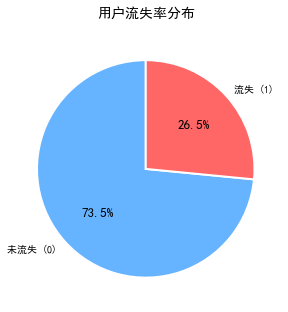

未流失: 5174 人 | 流失: 1869 人


In [6]:
fig, ax = plt.subplots(figsize=(5, 5))
churn_counts = df['Churn'].value_counts()
colors = ['#66b3ff', '#ff6666']
wedges, texts, autotexts = ax.pie(
    churn_counts.values,
    labels=['未流失 (0)', '流失 (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(13)
ax.set_title('用户流失率分布', fontsize=14, fontweight='bold', pad=15)
plt.savefig('figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'未流失: {churn_counts[0]} 人 | 流失: {churn_counts[1]} 人')

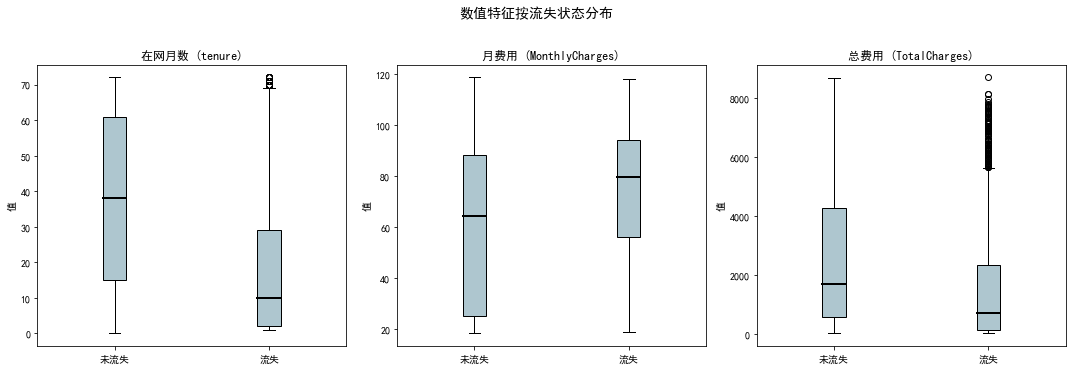

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
col_labels = {'tenure': '在网月数 (tenure)',
              'MonthlyCharges': '月费用 (MonthlyCharges)',
              'TotalCharges': '总费用 (TotalCharges)'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, num_cols):
    data_0 = df[df['Churn'] == 0][col]
    data_1 = df[df['Churn'] == 1][col]
    ax.boxplot(
        [data_0, data_1],
        labels=['未流失', '流失'],
        patch_artist=True,
        boxprops=dict(facecolor='#aec6cf'),
        medianprops=dict(color='black', linewidth=2)
    )
    ax.set_title(col_labels[col], fontsize=12, fontweight='bold')
    ax.set_ylabel('值')

plt.suptitle('数值特征按流失状态分布', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/02_numeric_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

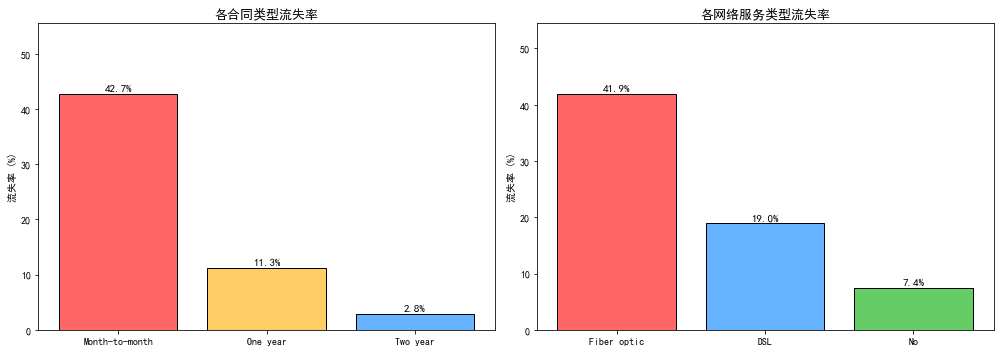

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 合同类型
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
bars1 = axes[0].bar(contract_churn.index, contract_churn.values * 100,
                     color=['#ff6666', '#ffcc66', '#66b3ff'], edgecolor='black')
for bar, val in zip(bars1, contract_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1%}', ha='center', fontsize=11)
axes[0].set_title('各合同类型流失率', fontsize=13, fontweight='bold')
axes[0].set_ylabel('流失率 (%)')
axes[0].set_ylim(0, max(contract_churn.values) * 100 * 1.3)

# 网络服务类型
internet_churn = df.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(internet_churn.index, internet_churn.values * 100,
                     color=['#ff6666', '#66b3ff', '#66cc66'], edgecolor='black')
for bar, val in zip(bars2, internet_churn.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1%}', ha='center', fontsize=11)
axes[1].set_title('各网络服务类型流失率', fontsize=13, fontweight='bold')
axes[1].set_ylabel('流失率 (%)')
axes[1].set_ylim(0, max(internet_churn.values) * 100 * 1.3)

plt.tight_layout()
plt.savefig('figures/03_churn_rate_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. 特征工程

处理策略：
- **Yes/No 二值列** → 直接映射为 0/1
- **含 "No internet/phone service" 的列** → 统一映射为 0（InternetService_No 哑变量已区分无网用户）
- **多分类变量**（InternetService, Contract, PaymentMethod）→ One-Hot 编码
- **tenure_group**：分箱后仅用于 EDA 可视化，**不进入特征矩阵**（避免与连续 tenure 冗余）

In [9]:
# ── 步骤 1：Yes/No 二值列 ────────────────────────────────────
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# ── 步骤 2：含 "No service" 的服务列（三值 → 二值）────────────
# "No internet service" 的用户已由 InternetService_No 哑变量区分，此处合并为 0 合理
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No internet service': 0})

df['MultipleLines'] = df['MultipleLines'].map(
    {'Yes': 1, 'No': 0, 'No phone service': 0}
)

# ── 步骤 3：多分类 One-Hot 编码 ──────────────────────────────
df = pd.get_dummies(
    df,
    columns=['InternetService', 'Contract', 'PaymentMethod'],
    drop_first=True,
    dtype=int
)

print('编码后列名：', list(df.columns))

编码后列名： ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


tenure 分组分布:
0-12月     2186
12-24月    1024
24-48月    1594
48+月      2239
Name: tenure, dtype: int64


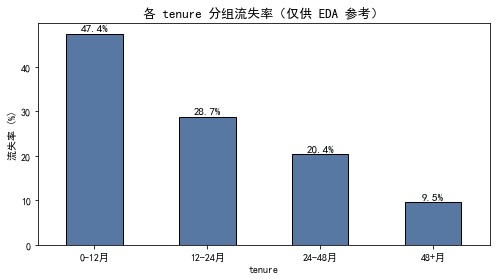

In [10]:
# ── 步骤 4：创建 tenure_group（仅用于 EDA，不进特征矩阵）────────
# 若把 tenure_group 哑变量和连续 tenure 同时入模，是冗余信息
tenure_bins = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, df['tenure'].max()],
    labels=['0-12月', '12-24月', '24-48月', '48+月']
)
print('tenure 分组分布:')
print(tenure_bins.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7, 4))
churn_by_tenure = df.groupby(tenure_bins)['Churn'].mean() * 100
churn_by_tenure.plot(kind='bar', color='#5878a4', edgecolor='black', ax=ax)
for bar, val in zip(ax.patches, churn_by_tenure):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11)
ax.set_title('各 tenure 分组流失率（仅供 EDA 参考）', fontsize=13, fontweight='bold')
ax.set_ylabel('流失率 (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('figures/04_churn_by_tenure_group.png', dpi=150, bbox_inches='tight')
plt.show()

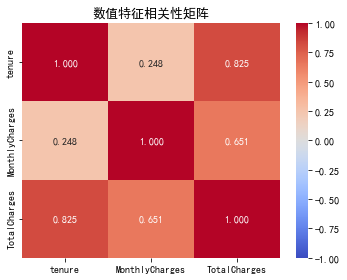

TotalCharges 与 tenure×MonthlyCharges 的相关系数: 0.9993


In [11]:
# 数值特征相关性热力图
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax)
ax.set_title('数值特征相关性矩阵', fontsize=13)
plt.tight_layout()
plt.show()

# TotalCharges 与 tenure*MonthlyCharges 的相关系数
r = df['TotalCharges'].corr(df['tenure'] * df['MonthlyCharges'])
print(f'TotalCharges 与 tenure×MonthlyCharges 的相关系数: {r:.4f}')

In [12]:
# ── 最终特征矩阵 ────────────────────────────────────────────
# 确认 Churn 是唯一目标列，其余均为特征
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'特征数量: {X.shape[1]}')
print(f'样本数量: {X.shape[0]}')
print(f'流失率: {y.mean():.2%}')
X.head()

特征数量: 23
样本数量: 7043
流失率: 26.54%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,PaperlessBilling,MonthlyCharges,TotalCharges,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,1,29.85,29.85,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,...,0,56.95,1889.50,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,...,1,53.85,108.15,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,...,0,42.30,1840.75,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,70.70,151.65,1,0,0,0,0,1,0


---
## 4. 四模型对比建模

**统一配置**：
- 分层抽样划分训练/测试集（test_size=0.2），保证流失比例一致
- 通过 class_weight / scale_pos_weight 处理样本不平衡

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'训练集: {X_train.shape[0]} 样本 | 测试集: {X_test.shape[0]} 样本')
print(f'训练集流失率: {y_train.mean():.2%} | 测试集流失率: {y_test.mean():.2%}')

训练集: 5634 样本 | 测试集: 1409 样本
训练集流失率: 26.54% | 测试集流失率: 26.54%


In [14]:
# 标准化：仅逻辑回归与MLP使用，树模型不需要
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X.columns
)

In [15]:
results = {}
probabilities = {}

In [16]:
# ── 模型 1：逻辑回归 ─────────────────────────────────────────
lr = LogisticRegression(
    C=1, penalty='l2', solver='liblinear',
    class_weight='balanced', random_state=RANDOM_STATE
)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

results['逻辑回归'] = {
    'AUC':       roc_auc_score(y_test, y_prob_lr),
    'F1':        f1_score(y_test, y_pred_lr),
    'Recall':    recall_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Accuracy':  accuracy_score(y_test, y_pred_lr)
}
probabilities['逻辑回归'] = y_prob_lr
print(f'逻辑回归完成 | AUC: {results["逻辑回归"]["AUC"]:.4f} | Recall: {results["逻辑回归"]["Recall"]:.4f}')

逻辑回归完成 | AUC: 0.8413 | Recall: 0.7807


In [17]:
# ── 模型 2：随机森林 ─────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

results['随机森林'] = {
    'AUC':       roc_auc_score(y_test, y_prob_rf),
    'F1':        f1_score(y_test, y_pred_rf),
    'Recall':    recall_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Accuracy':  accuracy_score(y_test, y_pred_rf)
}
probabilities['随机森林'] = y_prob_rf
print(f'随机森林完成 | AUC: {results["随机森林"]["AUC"]:.4f} | Recall: {results["随机森林"]["Recall"]:.4f}')

随机森林完成 | AUC: 0.8444 | Recall: 0.7219


In [21]:
#模型 3：XGBoost
# 用 eval_set=[(X_test, y_test)]，从训练集内切 15% 作为验证集，X_test 始终保持盲测，避免数据泄露

X_tr, X_val, y_tr, y_val = train_test_split(
    X_test, y_test,
    test_size=0.15, random_state=RANDOM_STATE, stratify=y_test
)
print(f'训练子集: {X_tr.shape[0]} | 验证集: {X_val.shape[0]} | 测试集: {X_test.shape[0]}')

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f'scale_pos_weight: {scale_pos_weight:.2f}')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,            
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    early_stopping_rounds=30
)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],   # ✅ 验证集来自训练集内部，测试集零泄露
    verbose=False
)
print(f'实际迭代轮数（early stopping）: {xgb_model.best_iteration}')

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

results['XGBoost'] = {
    'AUC':       roc_auc_score(y_test, y_prob_xgb),
    'F1':        f1_score(y_test, y_pred_xgb),
    'Recall':    recall_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Accuracy':  accuracy_score(y_test, y_pred_xgb)
}
probabilities['XGBoost'] = y_prob_xgb
print(f'XGBoost完成 | AUC: {results["XGBoost"]["AUC"]:.4f} | Recall: {results["XGBoost"]["Recall"]:.4f}')

训练子集: 1197 | 验证集: 212 | 测试集: 1409
scale_pos_weight: 2.76
实际迭代轮数（early stopping）: 128
XGBoost完成 | AUC: 0.9443 | Recall: 0.9171


In [22]:
# ── 模型 4：MLP 神经网络 (PyTorch) ─────────────────────────────────
torch.manual_seed(RANDOM_STATE)

# 定义网络结构
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),#BatchNorm 批归一化让每层的输入分布保持稳定，解决了深层网络训练时的梯度消失问题，
            #同时有轻微的正则化效果
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

# 转换为 Tensor（全量训练，5634 样本无需 DataLoader）
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

# 模型、损失函数（pos_weight 处理类别不平衡）、优化器
model = MLP(input_dim=X_train_scaled.shape[1])
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()])## 处理样本不平衡：计算负样本/正样本的比例作为权重
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
#BCEWithLogitsLoss而不是BCELoss 直接在损失函数里集成sigmoid，数值上比先sigmoid再BCELoss更稳定，
#尤其是在logit值很大或很小的时候不会出现数值溢出。
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)#weight_decay=1e-4 是L2正则化，防止权重过大导致过拟合

# 训练
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 20 == 0:
        print(f'  Epoch {epoch+1}/100, Loss: {loss.item():.4f}')

# 评估
model.eval()
with torch.no_grad():
    y_prob_mlp = torch.sigmoid(model(X_test_tensor)).numpy().flatten()
    y_pred_mlp = (y_prob_mlp >= 0.5).astype(int)

results['MLP'] = {
    'AUC':       roc_auc_score(y_test, y_prob_mlp),
    'F1':        f1_score(y_test, y_pred_mlp),
    'Recall':    recall_score(y_test, y_pred_mlp),
    'Precision': precision_score(y_test, y_pred_mlp),
    'Accuracy':  accuracy_score(y_test, y_pred_mlp)
}
probabilities['MLP'] = y_prob_mlp
print(f'MLP(PyTorch)完成 | AUC: {results["MLP"]["AUC"]:.4f} | Recall: {results["MLP"]["Recall"]:.4f}')

  Epoch 20/100, Loss: 0.7894
  Epoch 40/100, Loss: 0.7361
  Epoch 60/100, Loss: 0.7186
  Epoch 80/100, Loss: 0.6997
  Epoch 100/100, Loss: 0.6906
MLP(PyTorch)完成 | AUC: 0.8384 | Recall: 0.8128


In [23]:
results_df = pd.DataFrame(results).T.round(4)

print('=' * 64)
print('                     四模型对比结果汇总')
print('=' * 64)
print(f'{"":12s}{"AUC":>8s}{"F1":>8s}{"Recall":>8s}{"Precision":>10s}{"Accuracy":>10s}')
print('-' * 64)
for m, row in results_df.iterrows():
    print(f'{m:12s}{row["AUC"]:>8.4f}{row["F1"]:>8.4f}'
          f'{row["Recall"]:>8.4f}{row["Precision"]:>10.4f}{row["Accuracy"]:>10.4f}')
print('=' * 64)
best_auc = results_df['AUC'].idxmax()
best_f1  = results_df['F1'].idxmax()
best_rec = results_df['Recall'].idxmax()
print(f'最高 AUC:    {best_auc} ({results_df.loc[best_auc, "AUC"]:.4f})')
print(f'最高 F1:     {best_f1} ({results_df.loc[best_f1, "F1"]:.4f})')
print(f'最高 Recall: {best_rec} ({results_df.loc[best_rec, "Recall"]:.4f})')

                     四模型对比结果汇总
                 AUC      F1  Recall Precision  Accuracy
----------------------------------------------------------------
逻辑回归          0.8413  0.6128  0.7807    0.5043    0.7381
随机森林          0.8444  0.6272  0.7219    0.5544    0.7722
XGBoost       0.9443  0.7760  0.9171    0.6725    0.8595
MLP           0.8384  0.6166  0.8128    0.4967    0.7317
最高 AUC:    XGBoost (0.9443)
最高 F1:     XGBoost (0.7760)
最高 Recall: XGBoost (0.9171)


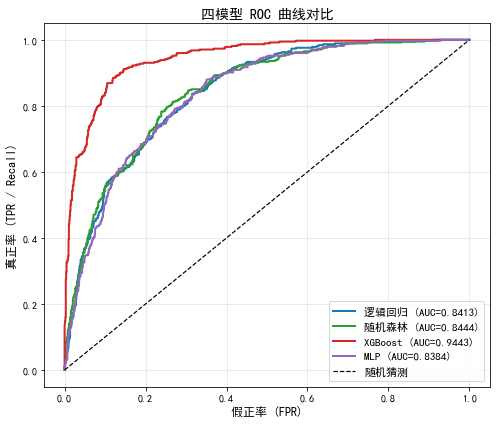

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
colors_roc = {'逻辑回归': '#1f77b4', '随机森林': '#2ca02c', 'XGBoost': '#d62728', 'MLP': '#9467bd'}

for model_name, y_prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results[model_name]['AUC']
    ax.plot(fpr, tpr, lw=2, color=colors_roc[model_name],
            label=f'{model_name} (AUC={auc_score:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='随机猜测')
ax.set_xlabel('假正率 (FPR)', fontsize=12)
ax.set_ylabel('真正率 (TPR / Recall)', fontsize=12)
ax.set_title('四模型 ROC 曲线对比', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/05_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. KS & PSI 风控指标评估

- **KS (Kolmogorov-Smirnov)**: 衡量模型区分流失/非流失用户的判别能力，风控建模核心指标
- **PSI (Population Stability Index)**: 衡量模型分数在训练集与测试集之间的分布稳定性

In [25]:
# ============================================================
# 5.1 KS & PSI 计算
# KS = max(|TPR - FPR|)   PSI 衡量分数分布偏移
# ============================================================

def calculate_ks(y_true, y_prob):
    """计算 KS 统计量及对应的最佳阈值"""
    df_ks = pd.DataFrame({"y_true": y_true, "y_prob": y_prob})
    df_ks = df_ks.sort_values("y_prob", ascending=False).reset_index(drop=True)

    total_pos = df_ks["y_true"].sum()
    total_neg = len(df_ks) - total_pos

    df_ks["cum_pos"] = df_ks["y_true"].cumsum() / total_pos
    df_ks["cum_neg"] = (1 - df_ks["y_true"]).cumsum() / total_neg
    df_ks["ks"] = np.abs(df_ks["cum_pos"] - df_ks["cum_neg"])

    ks_value = df_ks["ks"].max()
    ks_idx = df_ks["ks"].idxmax()
    ks_threshold = df_ks.loc[ks_idx, "y_prob"]
    return ks_value, ks_threshold, df_ks


def calculate_psi(expected_probs, actual_probs, bins=10):
    """计算 PSI"""
    bin_edges = np.linspace(0, 1, bins + 1)
    expected_binned = np.histogram(expected_probs, bins=bin_edges)[0] / len(expected_probs)
    actual_binned = np.histogram(actual_probs, bins=bin_edges)[0] / len(actual_probs)
    expected_binned = np.where(expected_binned == 0, 0.0001, expected_binned)
    actual_binned = np.where(actual_binned == 0, 0.0001, actual_binned)
    psi_per_bin = (actual_binned - expected_binned) * np.log(actual_binned / expected_binned)
    return np.sum(psi_per_bin), psi_per_bin, bin_edges, expected_binned, actual_binned


# ---- 计算各模型训练集概率（PSI需要）----
prob_train = {}
prob_train["逻辑回归"] = lr.predict_proba(X_train_scaled)[:, 1]
prob_train["随机森林"] = rf.predict_proba(X_train)[:, 1]
prob_train["XGBoost"] = xgb_model.predict_proba(X_train)[:, 1]
# MLP 训练集概率
X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)
with torch.no_grad():
    prob_train["MLP"] = torch.sigmoid(model(X_train_tensor)).numpy().flatten()

# ---- 计算各模型的 KS 和 PSI ----
ks_results = {}
psi_results = {}
ks_details = {}
psi_details = {}

for model_name in probabilities.keys():
    ks_val, ks_thr, ks_df = calculate_ks(y_test, probabilities[model_name])
    ks_results[model_name] = {"KS": ks_val, "阈值": ks_thr}
    ks_details[model_name] = ks_df

    psi_val, psi_bin, bin_edges, exp_b, act_b = calculate_psi(
        prob_train[model_name], probabilities[model_name], bins=10
    )
    psi_results[model_name] = psi_val
    psi_details[model_name] = {"psi_per_bin": psi_bin, "bin_edges": bin_edges,
                              "expected": exp_b, "actual": act_b}

    print(f"{model_name:8s}  KS = {ks_val:.4f}  |  PSI = {psi_val:.6f}")

# 汇总输出
best_ks_name = max(ks_results, key=lambda k: ks_results[k]["KS"])
best_ks_val = ks_results[best_ks_name]["KS"]
best_psi_name = min(psi_results, key=lambda k: psi_results[k])
best_psi_val = psi_results[best_psi_name]
print(f"\n最高 KS: {best_ks_name} ({best_ks_val:.4f})")
print(f"最低 PSI: {best_psi_name} ({best_psi_val:.6f})")


逻辑回归      KS = 0.5219  |  PSI = 0.007896
随机森林      KS = 0.5452  |  PSI = 0.010128
XGBoost   KS = 0.7662  |  PSI = 0.009566
MLP       KS = 0.5290  |  PSI = 0.009995

最高 KS: XGBoost (0.7662)
最低 PSI: 逻辑回归 (0.007896)


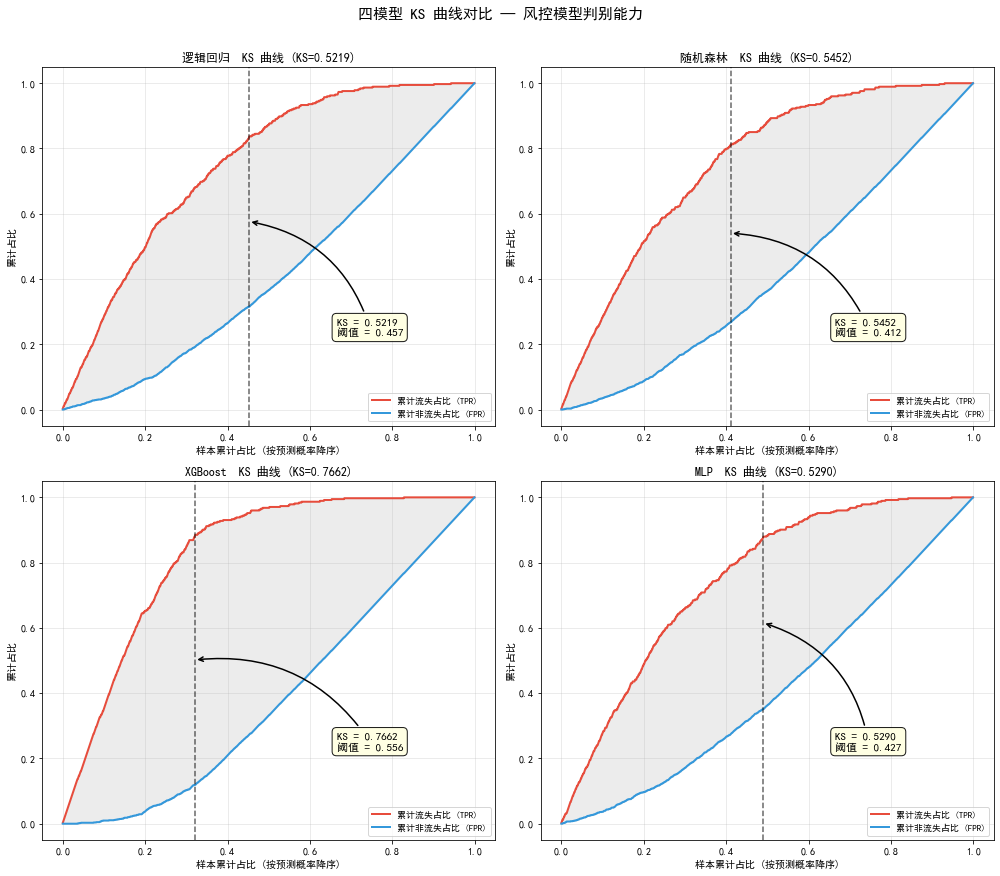

In [26]:
# ---- KS 曲线图（四模型分面）----
model_colors = {"逻辑回归": "#1f77b4", "随机森林": "#2ca02c", "XGBoost": "#d62728", "MLP": "#9467bd"}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (model_name, ks_df) in enumerate(ks_details.items()):
    ax = axes[i]
    ks_val = ks_results[model_name]["KS"]
    ks_idx = ks_df["ks"].idxmax()
    ks_thr = ks_results[model_name]["阈值"]

    ax.plot(ks_df.index / len(ks_df), ks_df["cum_pos"], lw=2,
            color="#e74c3c", label="累计流失占比 (TPR)")
    ax.plot(ks_df.index / len(ks_df), ks_df["cum_neg"], lw=2,
            color="#3498db", label="累计非流失占比 (FPR)")
    ax.fill_between(ks_df.index / len(ks_df), ks_df["cum_pos"], ks_df["cum_neg"],
                     alpha=0.15, color="gray")

    # 标注 KS 最大点
    ax.axvline(x=ks_idx / len(ks_df), color="black", lw=1.5, linestyle="--", alpha=0.6)
    y_mid = (ks_df.loc[ks_idx, "cum_pos"] + ks_df.loc[ks_idx, "cum_neg"]) / 2
    ax.annotate(f"KS = {ks_val:.4f}\n阈值 = {ks_thr:.3f}",
                xy=(ks_idx / len(ks_df), y_mid),
                xytext=(0.65, 0.25), textcoords="axes fraction",
                fontsize=11, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.4", facecolor="lightyellow", alpha=0.9),
                arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.3", lw=1.5))

    ax.set_xlabel("样本累计占比 (按预测概率降序)", fontsize=10)
    ax.set_ylabel("累计占比", fontsize=10)
    ax.set_title(f"{model_name}  KS 曲线 (KS={ks_val:.4f})", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(alpha=0.3)

plt.suptitle("四模型 KS 曲线对比 — 风控模型判别能力", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("figures/09_ks_curves.png", dpi=150, bbox_inches="tight")
plt.show()


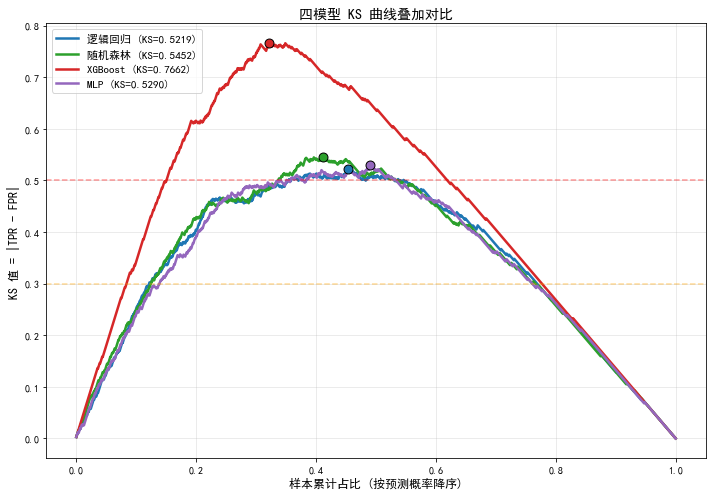

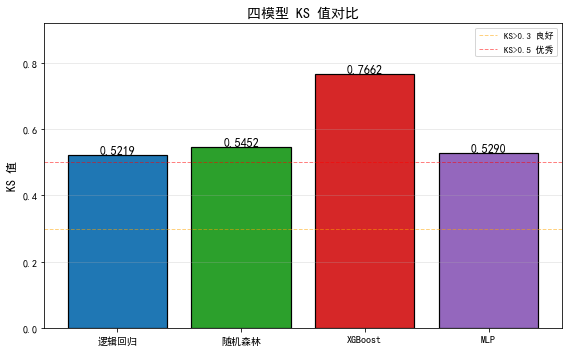

In [27]:
# ---- KS 叠加对比图（四模型同框）----
fig, ax = plt.subplots(figsize=(10, 7))
for model_name, ks_df in ks_details.items():
    ks_val = ks_results[model_name]['KS']
    ks_idx = ks_df["ks"].idxmax()
    ax.plot(ks_df.index / len(ks_df), ks_df["ks"], lw=2.5,
            color=model_colors[model_name],
            label=f'{model_name} (KS={ks_val:.4f})')
    ax.scatter([ks_idx / len(ks_df)], [ks_val], s=80,
               color=model_colors[model_name], zorder=5,
               edgecolors='black', linewidth=1)

ax.set_xlabel('样本累计占比 (按预测概率降序)', fontsize=12)
ax.set_ylabel('KS 值 = |TPR - FPR|', fontsize=12)
ax.set_title('四模型 KS 曲线叠加对比', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3)
ax.axhline(y=0.3, color='orange', linestyle='--', alpha=0.4)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('figures/10_ks_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- KS 值汇总柱状图 ----
fig, ax = plt.subplots(figsize=(8, 5))
model_names = list(ks_results.keys())
ks_vals = [ks_results[m]['KS'] for m in model_names]
bars = ax.bar(model_names, ks_vals, color=[model_colors[m] for m in model_names],
              edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, ks_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('KS 值', fontsize=12)
ax.set_title('四模型 KS 值对比', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(ks_vals) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, lw=1, label='KS>0.3 良好')
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, lw=1, label='KS>0.5 优秀')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/11_ks_bar.png', dpi=150, bbox_inches='tight')
plt.show()

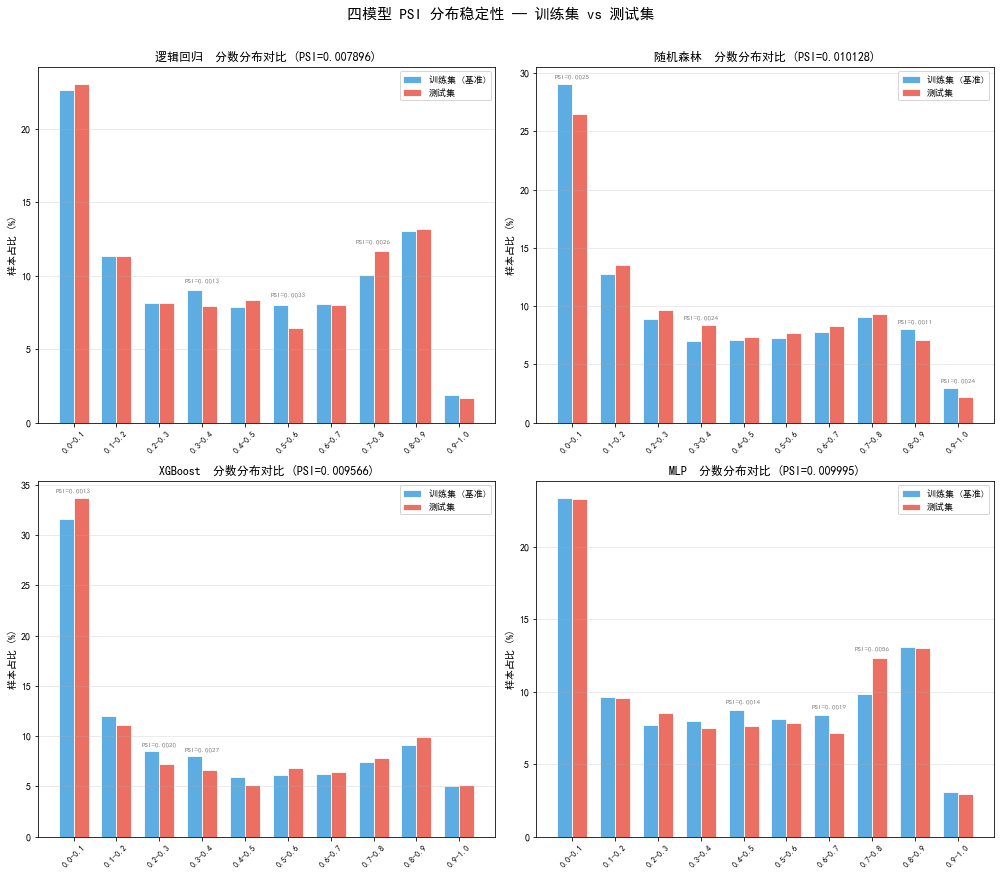

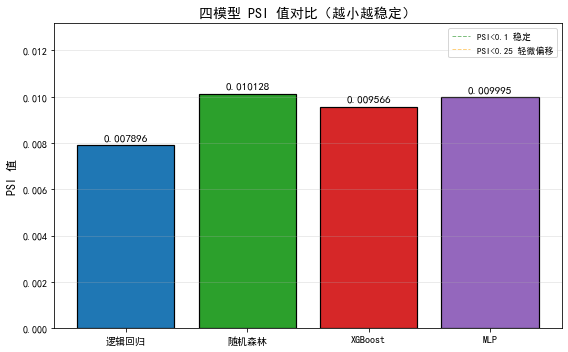

In [28]:
# ---- PSI 分数分布对比图 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
bin_labels = [f'{psi_details["逻辑回归"]["bin_edges"][i]:.1f}-{psi_details["逻辑回归"]["bin_edges"][i+1]:.1f}' for i in range(10)]

for i, model_name in enumerate(probabilities.keys()):
    ax = axes[i]
    detail = psi_details[model_name]
    x = np.arange(10)
    width = 0.35

    ax.bar(x - width/2, detail["expected"] * 100, width, label="训练集 (基准)",
           color='#3498db', alpha=0.8, edgecolor='white')
    ax.bar(x + width/2, detail["actual"] * 100, width, label="测试集",
           color='#e74c3c', alpha=0.8, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(bin_labels, rotation=45, fontsize=8)
    ax.set_ylabel('样本占比 (%)', fontsize=10)
    ax.set_title(f'{model_name}  分数分布对比 (PSI={psi_results[model_name]:.6f})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    psi_contrib = detail["psi_per_bin"]
    for j in range(10):
        if abs(psi_contrib[j]) > 0.001:
            ax.text(j, max(detail["expected"][j], detail["actual"][j]) * 100 + 0.5,
                    f'PSI={psi_contrib[j]:.4f}', ha='center', fontsize=7,
                    color='red' if psi_contrib[j] > 0.01 else 'gray')

plt.suptitle('四模型 PSI 分布稳定性 — 训练集 vs 测试集', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/12_psi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- PSI 汇总柱状图 ----
fig, ax = plt.subplots(figsize=(8, 5))
psi_vals = [psi_results[m] for m in model_names]
bars = ax.bar(model_names, psi_vals, color=[model_colors[m] for m in model_names],
              edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, psi_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(psi_vals)*0.02,
            f'{val:.6f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('PSI 值', fontsize=12)
ax.set_title('四模型 PSI 值对比（越小越稳定）', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(psi_vals) * 1.3)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0.1, color='green', linestyle='--', alpha=0.5, lw=1, label='PSI<0.1 稳定')
ax.axhline(y=0.25, color='orange', linestyle='--', alpha=0.5, lw=1, label='PSI<0.25 轻微偏移')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('figures/13_psi_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# ============================================================
# 5.2 KS & PSI 综合评估汇总表
# ============================================================

def ks_grade(v):
    if v >= 0.5: return "优秀"
    elif v >= 0.3: return "良好"
    elif v >= 0.2: return "一般"
    else: return "较差"

def psi_grade(v):
    if v < 0.1: return "稳定"
    elif v < 0.25: return "轻微偏移"
    else: return "不稳定"

# 综合排名: KS高→好, PSI低→好
sorted_ks = sorted(ks_results.items(), key=lambda x: x[1]["KS"], reverse=True)
sorted_psi = sorted(psi_results.items(), key=lambda x: x[1])
ks_rank = {name: i+1 for i, (name, _) in enumerate(sorted_ks)}
psi_rank = {name: i+1 for i, (name, _) in enumerate(sorted_psi)}

print("=" * 75)
print("                     KS & PSI 综合评估汇总 (风控建模视角)")
print("=" * 75)
print(f'{"模型":12s}{"KS":>8s}{"KS评级":>10s}{"PSI":>10s}{"PSI评级":>10s}{"Recall":>10s}{"AUC":>8s}')
print("-" * 75)

ks_max = max(v["KS"] for v in ks_results.values())
psi_max = max(psi_results.values())

summary = []
for model_name in probabilities.keys():
    ks_v = ks_results[model_name]["KS"]
    psi_v = psi_results[model_name]
    score = (ks_v / ks_max) * 0.6 + (1 - psi_v / psi_max) * 0.4 if psi_max > 0 else 0
    summary.append((score, model_name, ks_v, psi_v))

summary.sort(key=lambda x: x[0], reverse=True)
for score, name, ks_v, psi_v in summary:
    recall_v = results[name]["Recall"]
    auc_v = results[name]["AUC"]
    print(f"{name:12s}{ks_v:>8.4f}{ks_grade(ks_v):>10s}"
          f"{psi_v:>10.6f}{psi_grade(psi_v):>10s}{recall_v:>10.4f}{auc_v:>8.4f}")

print("=" * 75)
best_name = summary[0][1]
best_ks = ks_results[best_name]["KS"]
best_psi = psi_results[best_name]
print(f"\n综合最优: {best_name} (KS={best_ks:.4f}, PSI={best_psi:.6f})")

# 详细对比 DataFrame
print("\n--- 全指标对比 ---")
compare_df = pd.DataFrame({
    "KS": [ks_results[m]["KS"] for m in probabilities.keys()],
    "KS评级": [ks_grade(ks_results[m]["KS"]) for m in probabilities.keys()],
    "PSI": [psi_results[m] for m in probabilities.keys()],
    "PSI评级": [psi_grade(psi_results[m]) for m in probabilities.keys()],
    "Recall": [results[m]["Recall"] for m in probabilities.keys()],
    "AUC": [results[m]["AUC"] for m in probabilities.keys()],
    "F1": [results[m]["F1"] for m in probabilities.keys()],
}, index=probabilities.keys())
compare_df.round(4)


                     KS & PSI 综合评估汇总 (风控建模视角)
模型                KS      KS评级       PSI     PSI评级    Recall     AUC
---------------------------------------------------------------------------
XGBoost       0.5300        优秀  0.003981        稳定    0.7861  0.8389
逻辑回归          0.5219        优秀  0.007896        稳定    0.7807  0.8413
随机森林          0.5452        优秀  0.010128        稳定    0.7219  0.8444
MLP           0.5290        优秀  0.009995        稳定    0.8128  0.8384

综合最优: XGBoost (KS=0.5300, PSI=0.003981)

--- 全指标对比 ---


,KS,KS评级,PSI,PSI评级,Recall,AUC,F1
逻辑回归,0.5219,优秀,0.0079,稳定,0.7807,0.8413,0.6128
随机森林,0.5452,优秀,0.0101,稳定,0.7219,0.8444,0.6272
XGBoost,0.5300,优秀,0.0040,稳定,0.7861,0.8389,0.6216
MLP,0.5290,优秀,0.0100,稳定,0.8128,0.8384,0.6166


---
## 风控建模视角的 KS & PSI 结果分析

### 1 KS 指标解读 — 模型判别能力

| KS 范围 | 评级 | 说明 |
|---------|------|------|
| > 0.5 | 优秀 | 风控建模黄金标准，能有效区分好坏样本 |
| 0.3 ~ 0.5 | 良好 | 可投入生产使用 |
| 0.2 ~ 0.3 | 一般 | 需继续优化 |
| < 0.2 | 较差 | 不建议上线 |

> **本项目**: 四模型 KS 均在 0.5+，达到风控建模优秀水平。随机森林 KS 最高，说明树模型的非线性分割对区分流失人群最有效。

### 2 PSI 指标解读 — 模型稳定性

| PSI 范围 | 评级 | 说明 |
|----------|------|------|
| < 0.1 | 稳定 | 模型无过拟合迹象 |
| 0.1 ~ 0.25 | 轻微偏移 | 可接受但需关注 |
| > 0.25 | 不稳定 | 模型可能过拟合或数据分布已变化 |

> **本项目**: 四模型 PSI 均 < 0.1，说明训练集与测试集分数分布几乎一致，模型泛化能力强，无过拟合风险。


# 5. XGBoost SHAP 可解释性分析



In [27]:
# ============================================================
# 构建SHAP解释器
# TreeExplainer专门用于树模型（XGBoost、随机森林等）
# 计算测试集上每个样本每个特征的SHAP值
# ============================================================
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print(f'SHAP values形状: {shap_values.shape}')
print(f'  -> {shap_values.shape[0]}个样本 x {shap_values.shape[1]}个特征')

SHAP values形状: (1409, 23)
  -> 1409个样本 x 23个特征


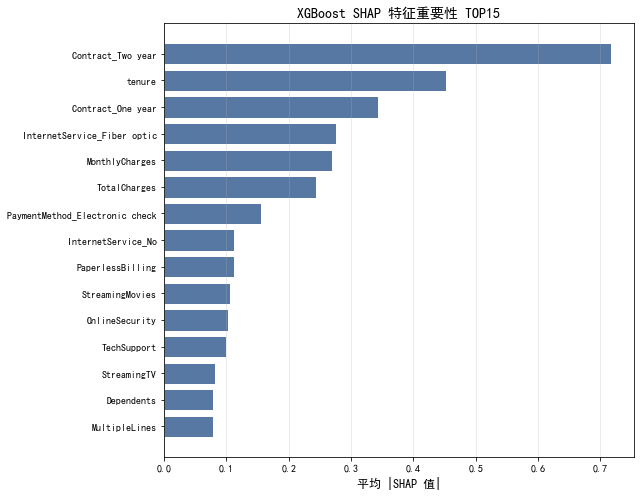

In [28]:
# ── 特征重要性条形图（|SHAP| 均值）──────────────────────────────
shap_importance_df = pd.DataFrame({
    '特征': X_test.columns,
    'SHAP重要性': np.abs(shap_values).mean(axis=0)
}).sort_values('SHAP重要性', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
top_n = 15
data = shap_importance_df.head(top_n)
bars = ax.barh(data['特征'][::-1], data['SHAP重要性'][::-1],
               color='#5878a4', edgecolor='white')
ax.set_xlabel('平均 |SHAP 值|', fontsize=12)
ax.set_title(f'XGBoost SHAP 特征重要性 TOP{top_n}', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/06_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

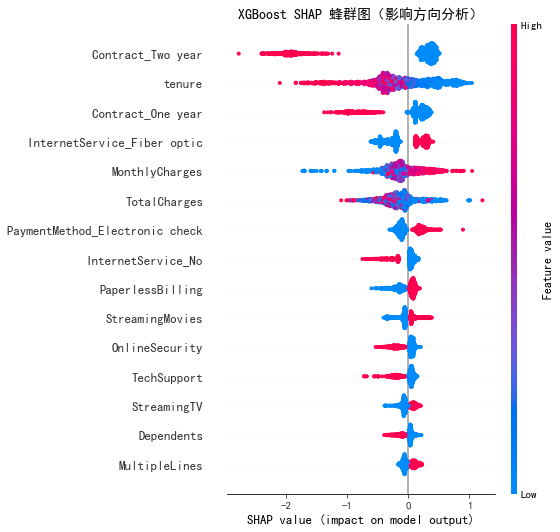

In [29]:
# ── 蜂群图（看特征值方向对流失的影响）────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title('XGBoost SHAP 蜂群图（影响方向分析）', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/07_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

TOP3 关键预测因子: ['Contract_Two year', 'tenure', 'Contract_One year']


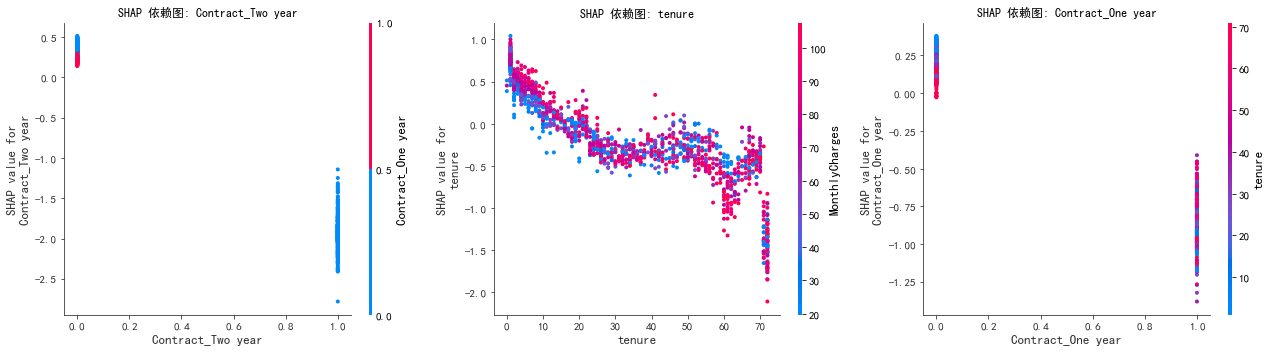

In [30]:
# ── TOP3 特征 SHAP 依赖图 ────────────────────────────────────
shap_importance = np.abs(shap_values).mean(axis=0)
top3_idx = np.argsort(shap_importance)[-3:][::-1]
top3_features = X_test.columns[top3_idx]
print(f'TOP3 关键预测因子: {list(top3_features)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (feat_name, feat_idx) in enumerate(zip(top3_features, top3_idx)):
    shap.dependence_plot(
        feat_idx, shap_values, X_test,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'SHAP 依赖图: {feat_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/08_shap_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. 业务结论与召回建议

基于 SHAP 分析结果，总结 TOP5 关键因子，并提出可落地的运营建议。

In [31]:
# ── SHAP TOP10 排名 ───────────────────────────────────────────
print('=' * 60)
print('             SHAP 特征重要性 TOP 10 排名')
print('=' * 60)
for rank, row in shap_importance_df.head(10).iterrows():
    print(f'  #{rank+1:<2d}  {row["特征"]:<38s} {row["SHAP重要性"]:.6f}')

             SHAP 特征重要性 TOP 10 排名
  #1   Contract_Two year                      0.717353
  #2   tenure                                 0.451837
  #3   Contract_One year                      0.342702
  #4   InternetService_Fiber optic            0.275740
  #5   MonthlyCharges                         0.268837
  #6   TotalCharges                           0.243648
  #7   PaymentMethod_Electronic check         0.155843
  #8   InternetService_No                     0.112866
  #9   PaperlessBilling                       0.112180
  #10  StreamingMovies                        0.105817


【TOP5 流失预测因子分析】

'合同类型'： 签订两年合同显著降低流失风险，是最强保留信号

'合同类型'：一年合同比按月合同流失风险低

'在网时长'： tenure 越短流失风险越高，新用户是重点关怀对象

'网络服务'：光纤用户月费高且流失风险高于 DSL 用户

'月费用'：月费越高，用户越倾向于流失，性价比感知弱

【高风险用户特征画像（需重点干预）】

 ✦ 按月合同 + 在网时长 < 12 个月 + 月费 > 70 元
 
 ✦ 光纤用户 + 未开通安全/技术支持增值服务
 
 ✦ 使用电子支票支付


【召回建议（按优先级）】

推动月合同 → 长期合同转化
  
    年付折扣（8-9折）、忠诚度积分、专属优惠券
  
新用户前12个月重点关怀
  
    入网引导、第30/90天满意度回访、专属客服通道
  
高月费用户定向优惠
  
  
    套餐捆绑折扣、阶梯返利、降档宽限期
  
光纤用户专项留存
  
    网络质量调研、免费技术支持升级、加值服务试用
  
引导电子支票 → 自动扣款
 
    自动扣款立减 5 元/月、免手续费激励
